# Universidad del Gran Rosario — Ingeniería del Software
## Trabajo Práctico: Introducción a las Metodologías y Procesos de Ciencia de Datos
### Metodología: CRISP-DM

**Docentes:** Ing. Ignacio Sanseovich — Lic. Briant Gauna

**Estudiantes:** Estudiante 1 · Estudiante 2 · Estudiante 3 · Estudiante 4 · Estudiante 5 · Estudiante 6 · Estudiante 7 · Estudiante 8

---

# Fase 1 — Comprensión del Negocio (Business Understanding)

## 1. Problema de negocio

La diabetes es una de las enfermedades crónicas con mayor impacto en los sistemas de salud a nivel mundial. Según la Organización Mundial de la Salud, más de 422 millones de personas viven con diabetes, y la gran mayoría de los casos son prevenibles o manejables si se detectan a tiempo.

El problema central es que el diagnóstico suele llegar tarde. Los pacientes no presentan síntomas evidentes en etapas tempranas, y los estudios de laboratorio completos (HOMA-IR, HbA1c, curva de glucemia) son costosos y no siempre accesibles en centros de atención primaria. Esto genera un ciclo en el que la enfermedad avanza silenciosamente hasta producir complicaciones graves como nefropatía, retinopatía o neuropatía, cuyo tratamiento es exponencialmente más costoso.

**¿Puede un modelo predictivo ayudar a identificar pacientes en riesgo usando solo indicadores clínicos básicos?** Esa es la pregunta que guía este trabajo.

Se propone desarrollar un modelo de clasificación que, a partir de variables clínicas simples (obtenibles en una consulta de rutina), prediga si un paciente tiene o no diabetes. Esto permitiría priorizar derivaciones y estudios confirmatorios en los pacientes con mayor riesgo.

---

## 2. Objetivo del análisis

**Objetivo general:**  
Construir un modelo predictivo que permita clasificar pacientes como diabéticos o no diabéticos a partir de variables clínicas básicas, con el fin de facilitar el triaje temprano en centros de atención primaria y mejorar la eficiencia en la detección de la enfermedad.

**Objetivos específicos:**
1. Analizar y comprender las variables clínicas del dataset mediante análisis exploratorio de datos (EDA).
2. Identificar qué variables presentan mayor capacidad para diferenciar pacientes diabéticos de no diabéticos.
3. Preparar y limpiar los datos para su uso en modelos de aprendizaje automático.
4. Entrenar y comparar al menos dos modelos de clasificación supervisada.
5. Evaluar el rendimiento de los modelos con métricas adecuadas para el contexto clínico.
6. Proponer un plan de despliegue aplicable en un entorno real de salud.

---

## 3. Stakeholders del negocio

Para comprender el impacto de esta solución, es necesario identificar a todos los actores involucrados en el problema:

| Stakeholder | Rol en el negocio |
|---|---|
| Ministerio de Salud | Financiador y regulador del sistema de salud pública |
| Médicos de atención primaria | Usuarios directos del modelo de predicción |
| Pacientes | Beneficiarios finales de un diagnóstico oportuno |
| Obras sociales y aseguradoras | Financiadores que buscan reducir costos de tratamientos avanzados |
| Equipos de enfermería | Personal que puede operar la herramienta en el primer contacto con el paciente |
| Equipo de Ciencia de Datos | Responsables de construir, mantener y actualizar el modelo |

---

## 4. Impacto de la solución por stakeholder

La justificación de este proyecto no es solo técnica: cada stakeholder tiene un interés concreto en que el modelo funcione bien.

**Ministerio de Salud**  
Un diagnóstico temprano reduce drásticamente el costo por paciente a lo largo del tiempo. El costo promedio de tratar complicaciones crónicas de diabetes (diálisis, amputaciones, hospitalizaciones) supera en hasta 10 veces el costo del triaje y control temprano. Un modelo de este tipo, escalable a nivel nacional, puede representar un ahorro significativo en el presupuesto sanitario.

**Médicos de atención primaria**  
En la consulta diaria, el médico atiende decenas de pacientes. Contar con una herramienta que, en segundos, señale cuáles pacientes tienen mayor riesgo permite priorizar recursos y ordenar estudios confirmatorios solo donde es necesario. No reemplaza al médico: lo asiste en la toma de decisiones.

**Pacientes**  
El impacto más humano: un diagnóstico temprano mejora directamente la calidad de vida. Un paciente detectado a tiempo puede modificar su dieta, iniciar tratamiento y evitar las complicaciones más graves. Para muchos pacientes, especialmente en zonas de acceso limitado al sistema de salud, esta herramienta puede marcar una diferencia real.

**Obras sociales y aseguradoras**  
Financieramente, es más barato prevenir que tratar. La implementación de un sistema de detección temprana reduce la incidencia de internaciones por complicaciones, que representan los eventos de mayor costo dentro del sistema.

**Equipo de Ciencia de Datos**  
Este proyecto representa un caso de aplicación real donde las decisiones del modelo tienen consecuencias concretas sobre personas. Eso implica una responsabilidad adicional: no solo importa la precisión del modelo, sino también la transparencia, la explicabilidad y el monitoreo continuo.

---
# Fase 2 — Comprensión de los Datos (Data Understanding)

## 1. Descripción del dataset

El dataset utilizado es el **Pima Indians Diabetes Database**, recopilado por el National Institute of Diabetes and Digestive and Kidney Diseases (NIDDK) de los Estados Unidos. Fue construido a partir de un estudio clínico sobre mujeres de ascendencia Pima (pueblo indígena del suroeste de EEUU), una población con alta prevalencia de diabetes tipo 2, lo que lo convierte en un caso de estudio clínicamente relevante.

El dataset contiene **768 registros**, cada uno representando una paciente mujer mayor de 21 años, y **8 variables predictoras** numéricas que describen indicadores clínicos básicos. La variable objetivo es binaria: indica si la paciente desarrolló diabetes dentro de los 5 años posteriores al estudio.

## 2. Metodología de adquisición

Para este trabajo se consideraron dos alternativas de adquisición de datos:

- **Opción A — Entorno real de producción:** Los datos se obtendrían mediante integración con el HIS (Health Information System) del centro de salud, vía exportación CSV o API REST. Cada consulta registrada en el sistema alimentaría automáticamente el pipeline de datos.
- **Opción B — Este trabajo (implementada):** Se utiliza el dataset público disponible en el repositorio de Jason Brownlee (mirror del UCI ML Repository), accesible directamente desde URL sin necesidad de descarga manual. Esto garantiza reproducibilidad del experimento.

## 3. Problemas de calidad identificados

Antes de cualquier análisis, es fundamental identificar los problemas potenciales que pueden afectar la calidad del modelado:

| Problema | Variables afectadas | Impacto | Tratamiento propuesto |
|---|---|---|---|
| Ceros fisiológicamente imposibles | Glucosa, Presión Arterial, Grosor de Piel, Insulina, IMC | Alto — sesgan distribuciones y afectan al modelo | Reemplazar por mediana de valores válidos |
| Desbalance de clases | Variable objetivo (≈35% positivos) | Medio — puede sesgar métricas | Priorizar F1 y ROC-AUC sobre Accuracy |
| Outliers extremos | Insulina, FuncionPedigree | Medio — afectan modelos sensibles a escala | Detectar con IQR, analizar caso a caso |
| Ausencia de datos nulos explícitos | — | Positivo — los ceros son el proxy de missings | Ya contemplado en el punto 1 |

El problema más importante es el de los **ceros inválidos**: variables como la glucosa o la presión arterial no pueden ser cero en un ser vivo. Estos valores son, en realidad, datos faltantes codificados como cero en el dataset original. Su tratamiento es una de las decisiones más relevantes de la fase de preparación.

## 4. Estrategia de proceso — Fases, tareas e instancias

| Fase CRISP-DM | Tarea general | Tarea específica | Instancia |
|---|---|---|---|
| Data Understanding | Exploración inicial | Shape, dtypes, describe, nulos | `df.info()`, `df.describe()` |
| Data Understanding | Análisis univariado | Distribución de cada variable | Boxplot + Histograma + KDE |
| Data Understanding | Análisis bivariado | Variables vs clase objetivo | Histograma y KDE por clase |
| Data Understanding | Análisis multivariado | Relaciones entre variables | Pairplot + Heatmap de correlación |
| Data Preparation | Limpieza | Imputación de ceros inválidos | Reemplazo por mediana |
| Data Preparation | Transformación | División train/test | `train_test_split` estratificado |
| Modeling | Entrenamiento modelo 1 | Árbol de Decisión | Búsqueda de profundidad óptima |
| Modeling | Entrenamiento modelo 2 | Random Forest | 200 árboles, max_depth=10 |
| Evaluation | Comparación | Métricas sobre test set | Accuracy, F1, ROC-AUC, Conf. Matrix |

In [ ]:
# ── Librerías ────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report, RocCurveDisplay
)

print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


In [ ]:
# ── Carga del dataset ────────────────────────────────────────────────────────
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
cols = ['Embarazos', 'Glucosa', 'PresionArterial', 'GrosortPiel',
        'Insulina', 'IMC', 'FuncionPedigree', 'Edad', 'Diabetes']

df = pd.read_csv(url, names=cols)

print(f"Dataset cargado correctamente.")
print(f"Dimensiones: {df.shape[0]} filas × {df.shape[1]} columnas")
print()
df.head(10)

Dataset cargado correctamente.
Dimensiones: 768 filas × 9 columnas



,Embarazos,Glucosa,PresionArterial,GrosortPiel,Insulina,IMC,FuncionPedigree,Edad,Diabetes
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,0,0,0.0,0.232,54,1


In [ ]:
# ── Estructura del dataset ───────────────────────────────────────────────────
print("=== Tipos de datos y valores no nulos ===")
df.info()
print()
print("=== Valores nulos por columna ===")
print(df.isnull().sum())
print()
print("==> No se detectan nulos explícitos. Los datos faltantes están codificados como cero.")

=== Tipos de datos y valores no nulos ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Embarazos        768 non-null    int64  
 1   Glucosa          768 non-null    int64  
 2   PresionArterial  768 non-null    int64  
 3   GrosortPiel      768 non-null    int64  
 4   Insulina         768 non-null    int64  
 5   IMC              768 non-null    float64
 6   FuncionPedigree  768 non-null    float64
 7   Edad             768 non-null    int64  
 8   Diabetes         768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB

=== Valores nulos por columna ===
Embarazos          0
Glucosa            0
PresionArterial    0
GrosortPiel        0
Insulina           0
IMC                0
FuncionPedigree    0
Edad               0
Diabetes           0
dtype: int64

==> No se detectan nulos explícitos. Los datos faltantes es

In [ ]:
# ── Estadística descriptiva ──────────────────────────────────────────────────
print("=== Estadística descriptiva ===")
df.describe().round(2)

=== Estadística descriptiva ===


,Embarazos,Glucosa,PresionArterial,GrosortPiel,Insulina,IMC,FuncionPedigree,Edad,Diabetes
count,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00
mean,3.85,120.89,69.11,20.54,79.80,31.99,0.47,33.24,0.35
std,3.37,31.97,19.36,15.95,115.24,7.88,0.33,11.76,0.48
min,0.00,0.00,0.00,0.00,0.00,0.00,0.08,21.00,0.00
25%,1.00,99.00,62.00,0.00,0.00,27.30,0.24,24.00,0.00
50%,3.00,117.00,72.00,23.00,30.50,32.00,0.37,29.00,0.00
75%,6.00,140.25,80.00,32.00,127.25,36.60,0.63,41.00,1.00
max,17.00,199.00,122.00,99.00,846.00,67.10,2.42,81.00,1.00


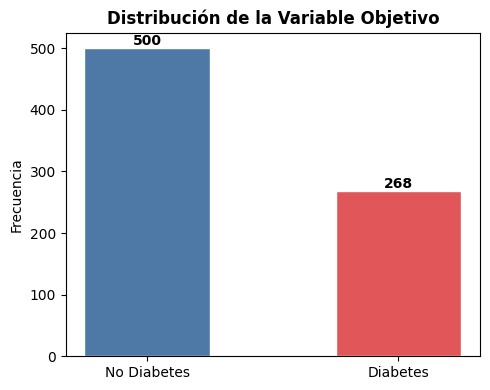

No Diabetes (0): 500 (65.1%)
Diabetes    (1): 268 (34.9%)

El dataset presenta un desbalance moderado (65/35). Se tendrá en cuenta al interpretar las métricas.


In [ ]:
# ── Balance de la variable objetivo ─────────────────────────────────────────
conteo = df['Diabetes'].value_counts()
categorias = ['No Diabetes', 'Diabetes']
valores = [conteo[0], conteo[1]]

plt.figure(figsize=(5, 4))
plt.bar(categorias, valores, color=['#4e79a7', '#e15759'], edgecolor='white', width=0.5)
plt.title('Distribución de la Variable Objetivo', fontweight='bold')
plt.ylabel('Frecuencia')
for i, v in enumerate(valores):
    plt.text(i, v + 5, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

print(f"No Diabetes (0): {conteo[0]} ({conteo[0]/len(df):.1%})")
print(f"Diabetes    (1): {conteo[1]} ({conteo[1]/len(df):.1%})")
print()
print("El dataset presenta un desbalance moderado (65/35). Se tendrá en cuenta al interpretar las métricas.")

---
# Fase 3 — Preparación de los Datos (Data Preparation)

## 1. Variables relevantes del estudio

A continuación se describe cada variable del dataset, su naturaleza estadística y su relevancia clínica:

| Variable | Descripción clínica | Tipo estadístico |
|---|---|---|
| Embarazos | Número de embarazos de la paciente | Discreta |
| Glucosa | Concentración de glucosa plasmática en prueba de tolerancia oral a los 2h (mg/dL) | Continua |
| PresionArterial | Presión arterial diastólica (mm Hg) | Continua |
| GrosortPiel | Grosor del pliegue cutáneo tricipital (mm) — proxy de grasa corporal | Continua |
| Insulina | Insulina sérica a las 2h post-carga (μU/ml) | Continua |
| IMC | Índice de masa corporal: peso(kg) / estatura(m)² | Continua |
| FuncionPedigree | Función de pedigrí de diabetes: pondera antecedentes familiares | Continua |
| Edad | Edad en años cumplidos al momento del estudio | Discreta |
| **Diabetes** | **Variable objetivo: 1 = diagnóstico positivo dentro de los 5 años, 0 = negativo** | **Binaria** |

## 2. Análisis estadístico descriptivo — resumen

Se realizará para cada variable: boxplot (para detectar outliers y dispersión), histograma (distribución de frecuencias) y curva de densidad (forma de la distribución). Luego se cruzarán las variables con la clase objetivo para identificar cuáles son más discriminantes.

## 3. Limpieza de datos

La estrategia de imputación elegida es reemplazar los ceros inválidos por la mediana de los valores válidos (no cero) de cada variable. Se elige la mediana sobre la media porque es más robusta ante la presencia de outliers, que son frecuentes en variables clínicas como la insulina.

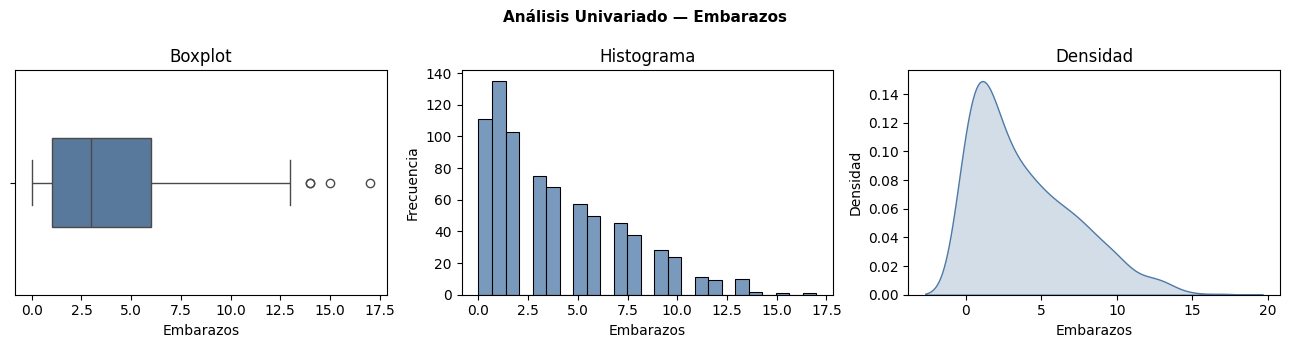

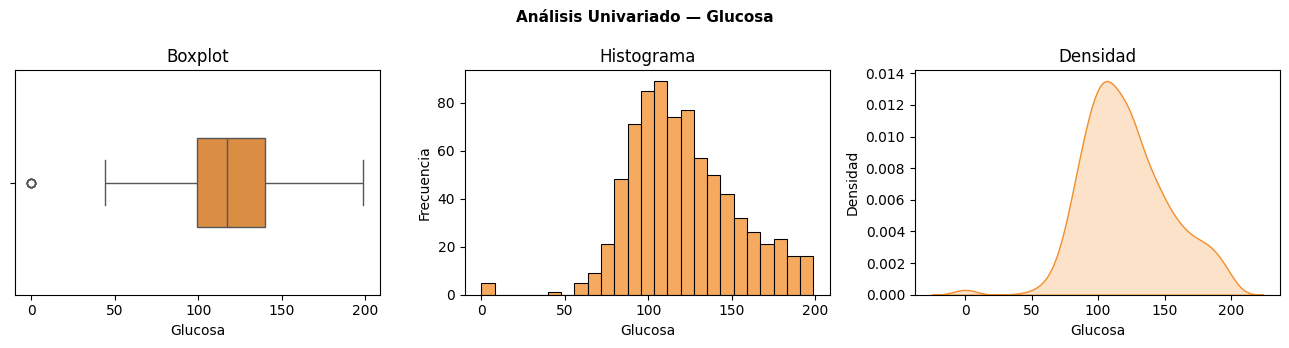

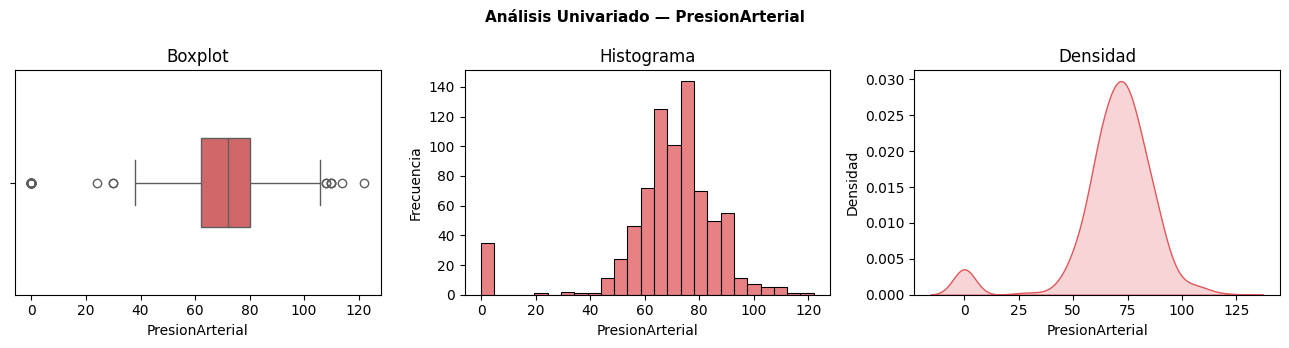

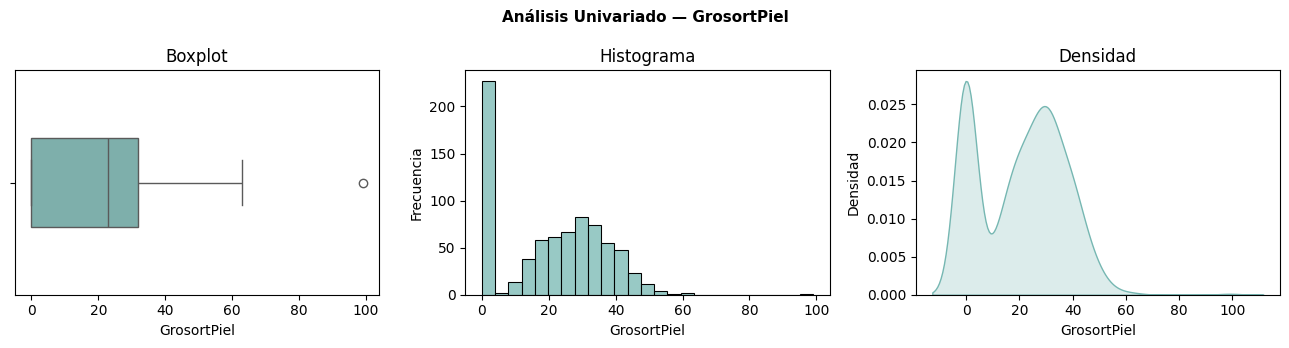

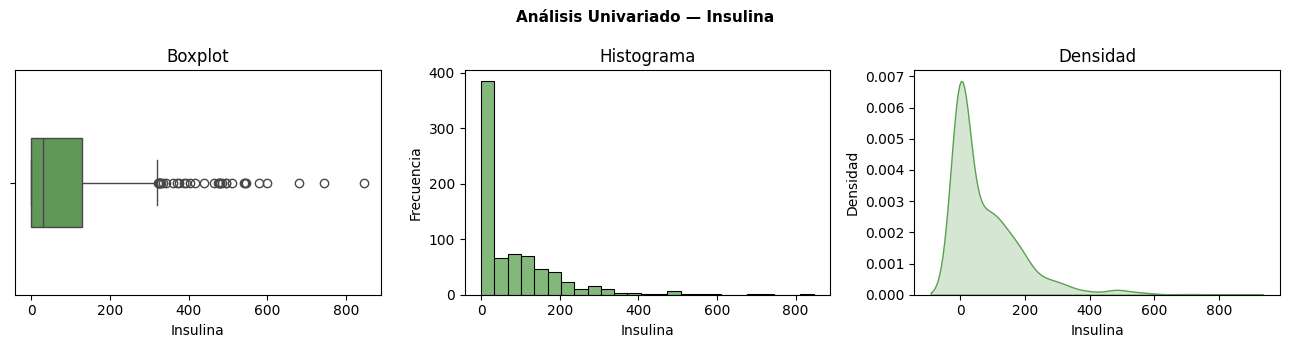

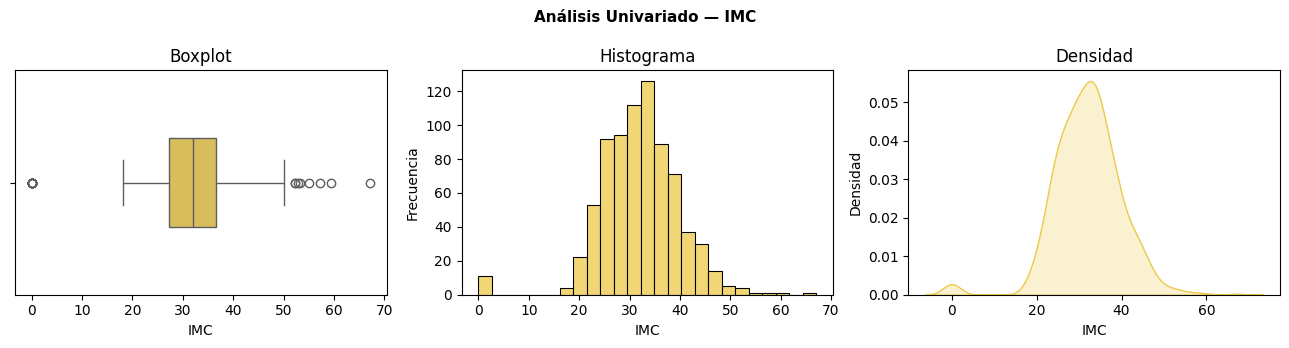

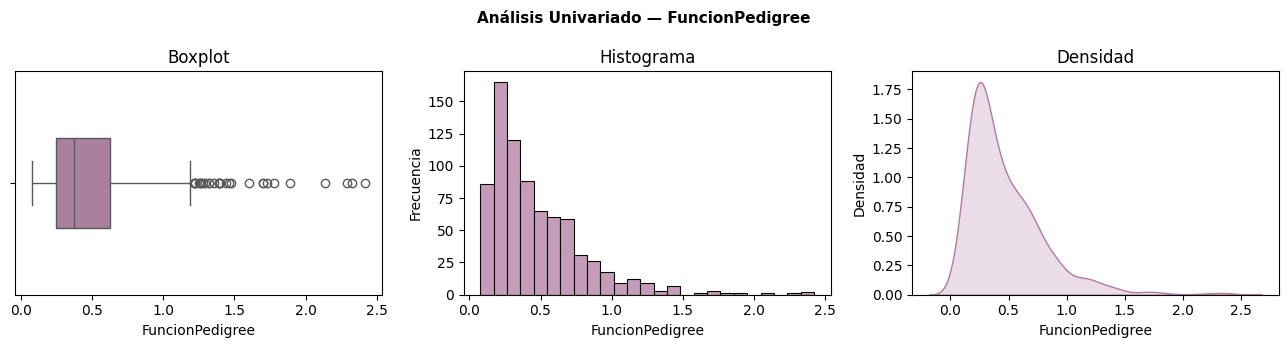

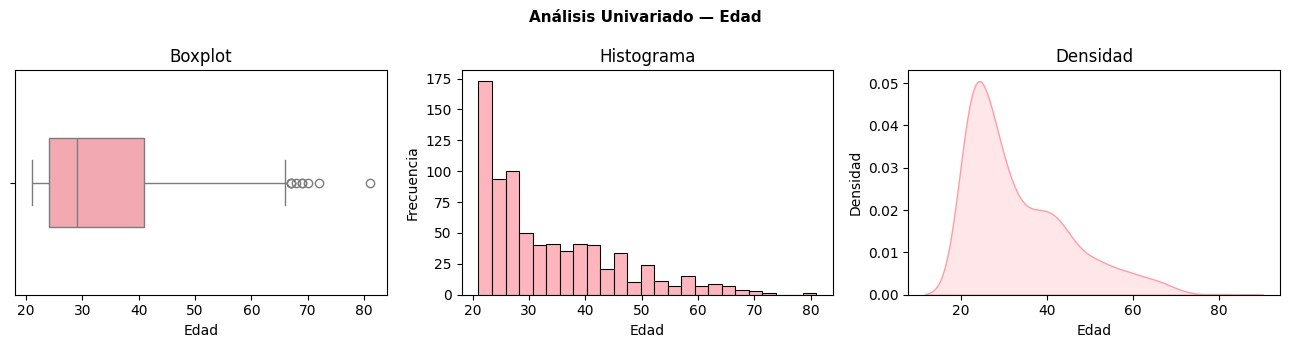

In [ ]:
# ── Análisis Univariado — Boxplot + Histograma + KDE por variable ─────────────
features = [c for c in df.columns if c != 'Diabetes']
colores = ['#4e79a7','#f28e2b','#e15759','#76b7b2','#59a14f','#edc948','#b07aa1','#ff9da7']

for i, var in enumerate(features):
    color = colores[i % len(colores)]
    fig, ax = plt.subplots(1, 3, figsize=(13, 3.5))

    sns.boxplot(data=df[var], ax=ax[0], orient='h', color=color, width=0.4)
    ax[0].set_title('Boxplot')
    ax[0].set_xlabel(var)

    sns.histplot(data=df[var], ax=ax[1], kde=False, color=color, bins=25)
    ax[1].set_title('Histograma')
    ax[1].set_xlabel(var)
    ax[1].set_ylabel('Frecuencia')

    sns.kdeplot(data=df[var], ax=ax[2], fill=True, color=color)
    ax[2].set_title('Densidad')
    ax[2].set_xlabel(var)
    ax[2].set_ylabel('Densidad')

    fig.suptitle(f'Análisis Univariado — {var}', fontweight='bold', fontsize=11)
    plt.tight_layout()
    plt.show()

### Conclusiones del Análisis Univariado

El análisis univariado permite obtener una primera lectura del comportamiento individual de cada variable. A continuación se sintetizan los hallazgos más relevantes:

| Variable | Min | Mediana | Max | Observaciones |
|---|---|---|---|---|
| Embarazos | 0 | 3 | 17 | Sesgo a la derecha. La mayoría de pacientes tiene entre 0 y 6 embarazos. |
| Glucosa | 0 | 117 | 199 | Distribución unimodal. **Ceros presentes (inválidos)**. Principal predictor esperado. |
| PresionArterial | 0 | 72 | 122 | Distribución aproximadamente normal. **Ceros presentes**. |
| GrosortPiel | 0 | 23 | 99 | Alta cantidad de ceros. Sesgo a la derecha. **Mayor volumen de imputación**. |
| Insulina | 0 | 30.5 | 846 | **Variable más problemática**: 48.7% de ceros, outliers extremos, fuerte sesgo. |
| IMC | 0 | 32.0 | 67.1 | Distribución aproximadamente normal. Algunos ceros inválidos. |
| FuncionPedigree | 0.078 | 0.37 | 2.42 | Sesgo pronunciado a la derecha. Sin ceros, pero con outliers relevantes. |
| Edad | 21 | 29 | 81 | Sesgo a la derecha. Mayoría de pacientes entre 21 y 40 años. |

**Hallazgo crítico:** La variable Insulina presenta el mayor problema de calidad con casi el 49% de sus valores como cero. Esto implica que la imputación en esta variable tendrá mayor impacto en el modelo, y sus resultados deben interpretarse con cautela.

In [ ]:
# ── Detección de ceros inválidos ──────────────────────────────────────────────
vars_invalidas = ['Glucosa', 'PresionArterial', 'GrosortPiel', 'Insulina', 'IMC']

print("=== Ceros fisiológicamente imposibles — proxy de datos faltantes ===")
print(f"{'Variable':<20} {'Cantidad':>10} {'Porcentaje':>12}")
print("-" * 45)
for v in vars_invalidas:
    n = (df[v] == 0).sum()
    print(f"{v:<20} {n:>10} {n/len(df):>11.1%}")

=== Ceros fisiológicamente imposibles — proxy de datos faltantes ===
Variable               Cantidad   Porcentaje
---------------------------------------------
Glucosa                       5        0.7%
PresionArterial              35        4.6%
GrosortPiel                 227       29.6%
Insulina                    374       48.7%
IMC                          11        1.4%


In [ ]:
# ── Imputación por mediana ────────────────────────────────────────────────────
df_clean = df.copy()

print("=== Imputación de ceros por mediana ===")
print(f"{'Variable':<20} {'Mediana usada':>15}")
print("-" * 38)
for v in vars_invalidas:
    mediana = df_clean[v][df_clean[v] != 0].median()
    df_clean[v] = df_clean[v].replace(0, mediana)
    print(f"{v:<20} {mediana:>15.2f}")

print()
print("Verificación — ceros restantes:")
print((df_clean[vars_invalidas] == 0).sum())
print("==> Imputación completada correctamente.")

=== Imputación de ceros por mediana ===
Variable               Mediana usada
--------------------------------------
Glucosa                       117.00
PresionArterial                72.00
GrosortPiel                    29.00
Insulina                      125.00
IMC                            32.30

Verificación — ceros restantes:
Glucosa            0
PresionArterial    0
GrosortPiel        0
Insulina           0
IMC                0
dtype: int64
==> Imputación completada correctamente.


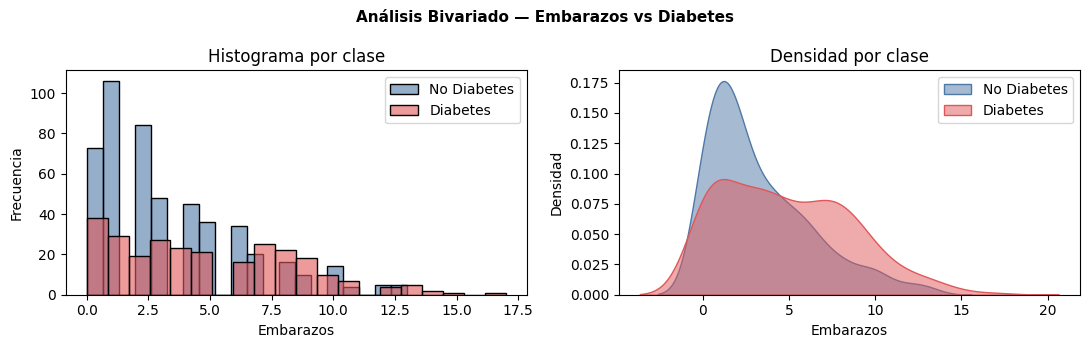

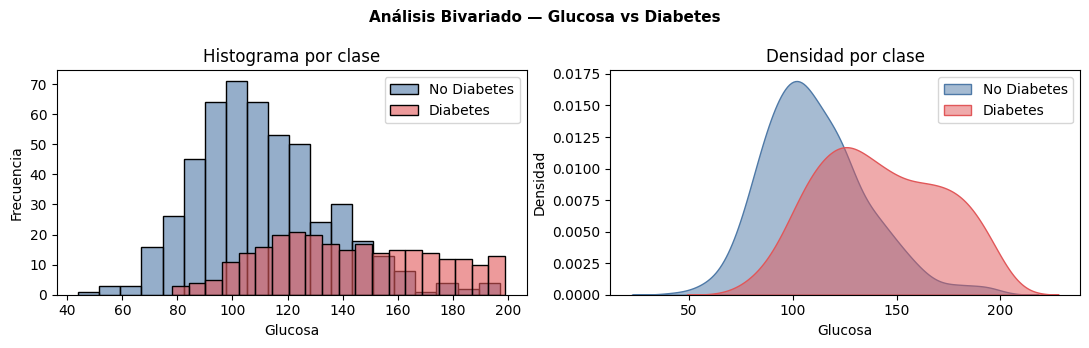

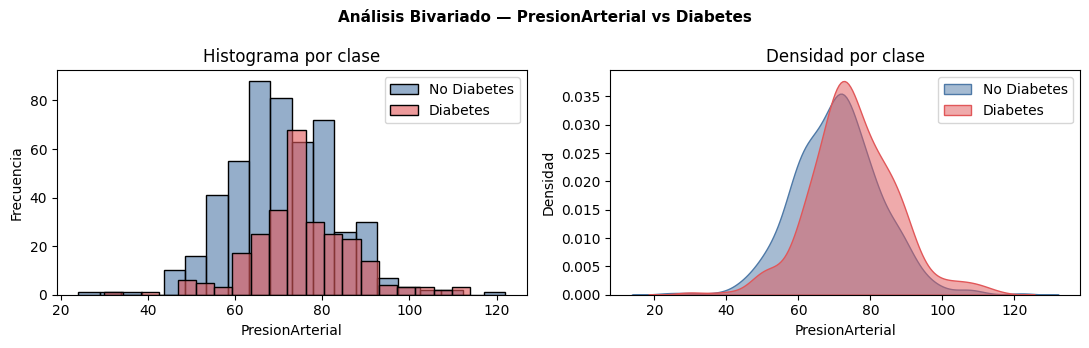

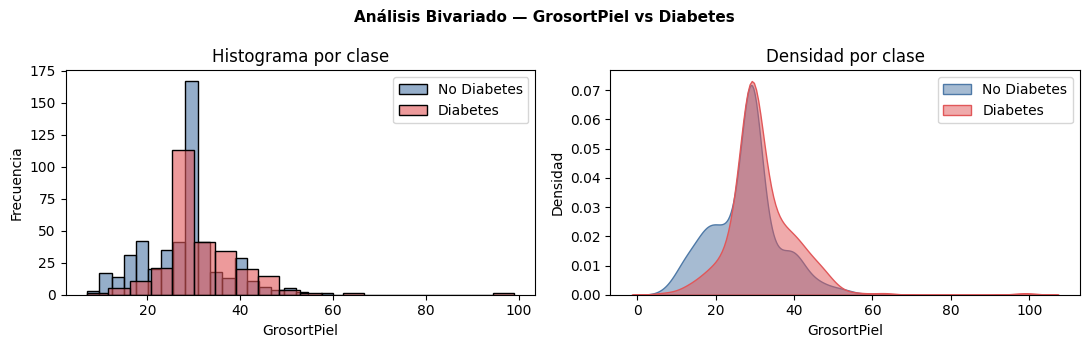

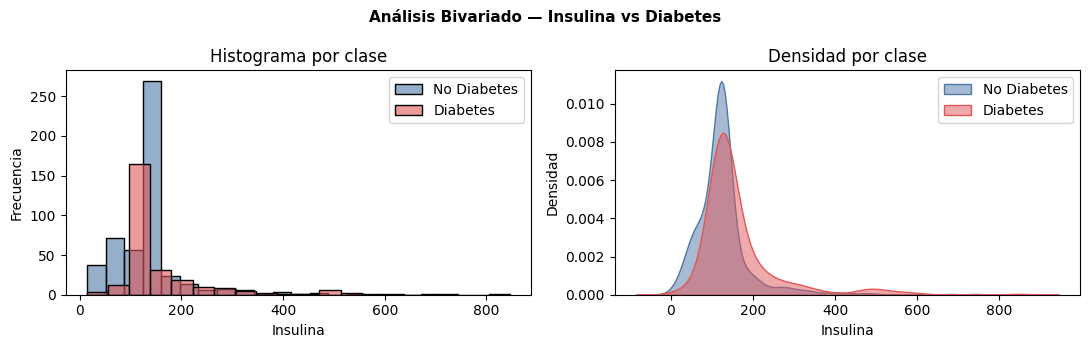

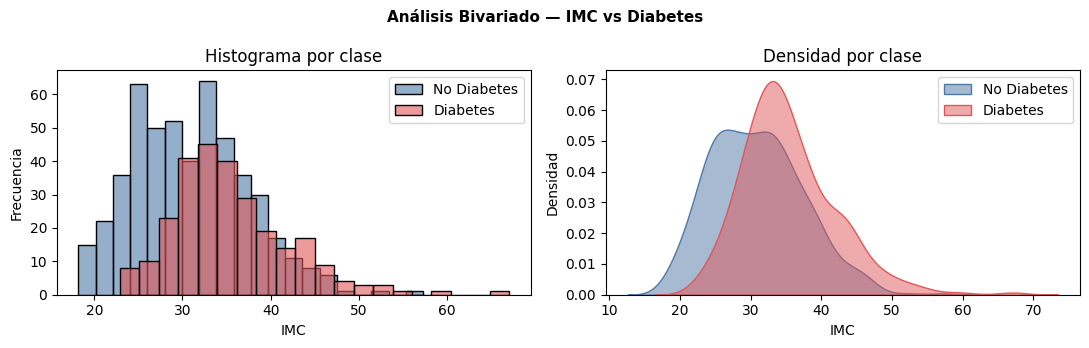

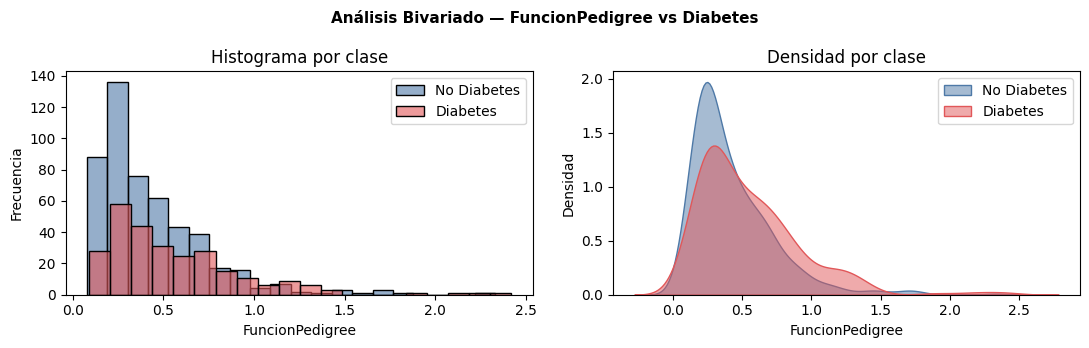

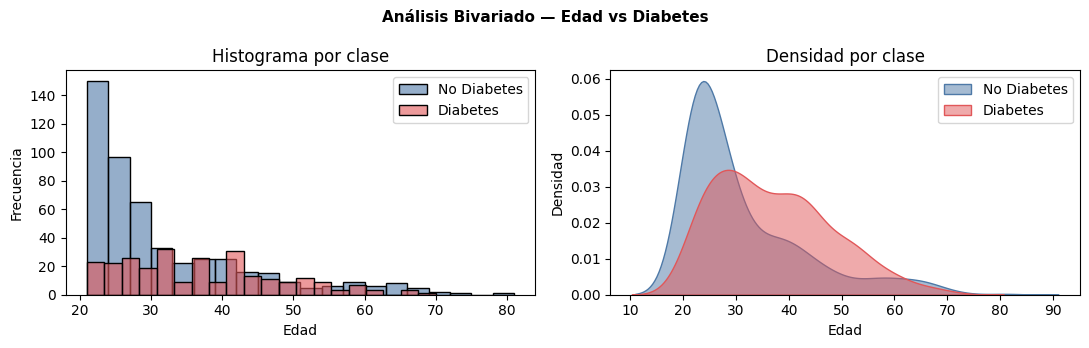

In [ ]:
# ── Análisis Bivariado — cada variable vs la clase objetivo ───────────────────
# Este análisis es clave para entender qué variables diferencian mejor las clases.

paleta = ['#4e79a7', '#e15759']
labels = ['No Diabetes', 'Diabetes']

for var in features:
    fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))

    for cls, color, label in zip([0, 1], paleta, labels):
        subset = df_clean[df_clean['Diabetes'] == cls][var]
        sns.histplot(subset, ax=ax[0], kde=False, color=color, label=label, alpha=0.6, bins=20)
    ax[0].set_title(f'Histograma por clase')
    ax[0].set_xlabel(var)
    ax[0].set_ylabel('Frecuencia')
    ax[0].legend()

    for cls, color, label in zip([0, 1], paleta, labels):
        subset = df_clean[df_clean['Diabetes'] == cls][var]
        sns.kdeplot(subset, ax=ax[1], fill=True, color=color, label=label, alpha=0.5)
    ax[1].set_title(f'Densidad por clase')
    ax[1].set_xlabel(var)
    ax[1].set_ylabel('Densidad')
    ax[1].legend()

    fig.suptitle(f'Análisis Bivariado — {var} vs Diabetes', fontweight='bold', fontsize=11)
    plt.tight_layout()
    plt.show()

### Conclusiones del Análisis Bivariado

El análisis bivariado revela qué variables tienen mayor capacidad discriminante entre las dos clases. Una variable es útil para el modelo cuando las distribuciones de las dos clases están claramente separadas; si se solapan completamente, la variable tiene poco poder predictivo.

| Variable | ¿Discrimina bien? | Observación |
|---|---|---|
| **Glucosa** | Sí — mayor separación | Los pacientes diabéticos concentran valores entre 140-180 mg/dL. Variable más discriminante. |
| **IMC** | Sí | Los diabéticos tienden a presentar IMC más elevado (>30). |
| **Edad** | Sí | Los pacientes diabéticos tienden a ser de mayor edad. |
| **FuncionPedigree** | Moderado | Los diabéticos presentan valores más altos, pero hay solapamiento. |
| **Embarazos** | Parcial | Los diabéticos tienen más embarazos en promedio, pero alta superposición. |
| **PresionArterial** | Bajo | Las distribuciones son muy similares entre clases. Aporte marginal. |
| **GrosortPiel** | Bajo-moderado | Cierta diferencia, pero alta superposición. |
| **Insulina** | Limitado | El alto volumen de imputación reduce la confiabilidad de esta variable. |

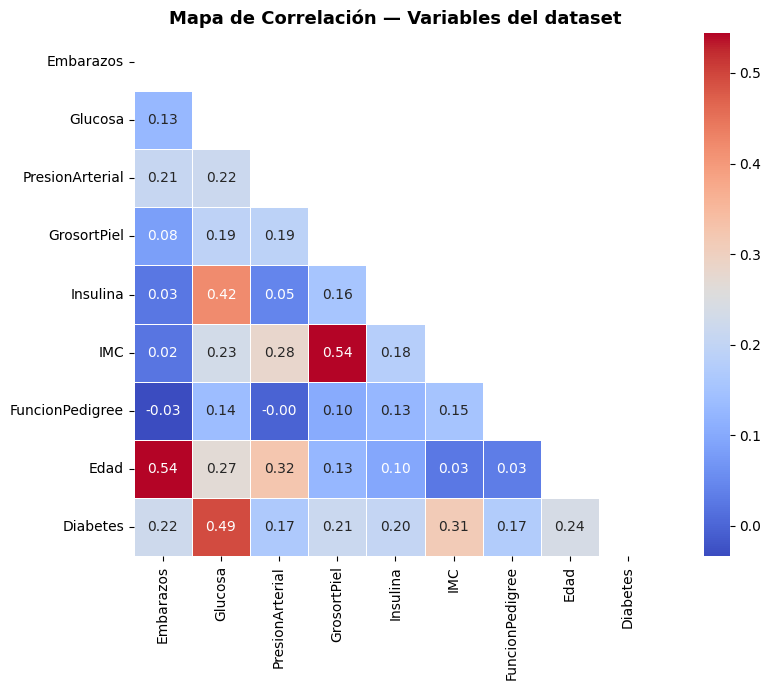

In [ ]:
# ── Análisis Multivariado — Matriz de Correlación ─────────────────────────────
plt.figure(figsize=(10, 7))
mask = np.triu(np.ones_like(df_clean.corr(), dtype=bool))
sns.heatmap(df_clean.corr(), annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, square=True, linewidths=0.5)
plt.title('Mapa de Correlación — Variables del dataset', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Análisis de correlaciones

La matriz de correlación permite detectar si existen variables redundantes (altamente correlacionadas entre sí) que no aporten información adicional al modelo.

| Variable 1 | Variable 2 | Correlación | Clasificación | Decisión |
|---|---|---|---|---|
| Glucosa | Diabetes | ~0.49 | Moderada-alta | **Mantener** — mayor correlación con objetivo |
| IMC | GrosortPiel | ~0.39 | Moderada | Mantener ambas — miden dimensiones distintas |
| Edad | Embarazos | ~0.54 | Moderada | Mantener ambas — aportan info diferente |
| Insulina | GrosortPiel | ~0.44 | Moderada | Mantener ambas |

**Conclusión:** No se detectan correlaciones extremas (>0.90) entre predictores. No es necesario eliminar variables por multicolinealidad. Se mantienen las 8 variables para el modelado y se dejará que el modelo determine la importancia relativa de cada una.

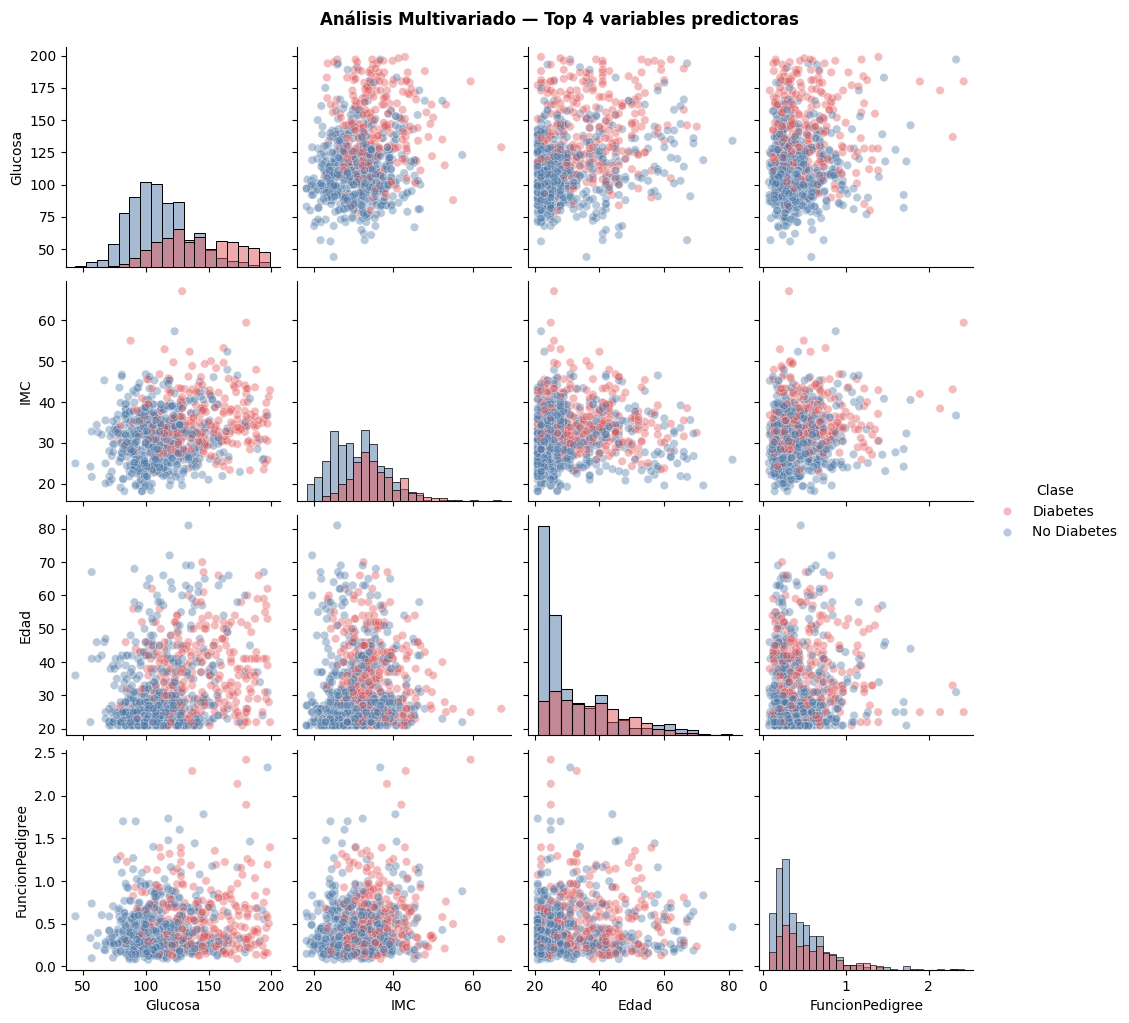

In [ ]:
# ── Análisis Multivariado — Pairplot ──────────────────────────────────────────
# Se seleccionan las 4 variables con mayor correlación con la variable objetivo
# para una visualización más clara de las relaciones entre variables.

vars_pairplot = ['Glucosa', 'IMC', 'Edad', 'FuncionPedigree', 'Diabetes']
df_pair = df_clean[vars_pairplot].copy()
df_pair['Clase'] = df_pair['Diabetes'].map({0: 'No Diabetes', 1: 'Diabetes'})

sns.pairplot(df_pair.drop('Diabetes', axis=1), hue='Clase',
             palette={'No Diabetes': '#4e79a7', 'Diabetes': '#e15759'},
             diag_kind='hist', plot_kws={'alpha': 0.4})
plt.suptitle('Análisis Multivariado — Top 4 variables predictoras', y=1.02, fontsize=12, fontweight='bold')
plt.show()

### Conclusiones del Análisis Multivariado

El pairplot confirma las observaciones del análisis bivariado: la **Glucosa** es la variable con mayor capacidad de separación entre clases, seguida por el **IMC** y la **Edad**. La **FuncionPedigree** aporta información adicional aunque con mayor solapamiento entre clases.

En los cruces entre variables (off-diagonal), se observa que la combinación **Glucosa + IMC** genera la separación más clara entre las dos poblaciones, lo que sugiere que estas dos variables serán las más relevantes en cualquier modelo de clasificación que se construya.

In [ ]:
# ── División train / test ─────────────────────────────────────────────────────
X = df_clean.drop('Diabetes', axis=1)
y = df_clean['Diabetes']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("=== División del dataset ===")
print(f"  Entrenamiento: {X_train.shape[0]} registros ({X_train.shape[0]/len(df):.0%}) — Positivos: {y_train.mean():.1%}")
print(f"  Test:          {X_test.shape[0]} registros ({X_test.shape[0]/len(df):.0%})  — Positivos: {y_test.mean():.1%}")
print()
print("→ Se usó stratify=y para preservar el balance de clases en ambos conjuntos.")

=== División del dataset ===
  Entrenamiento: 614 registros (80%) — Positivos: 34.9%
  Test:          154 registros (20%)  — Positivos: 35.1%

→ Se usó stratify=y para preservar el balance de clases en ambos conjuntos.


---
# Fase 4 — Modelado (Modeling)

## 1. Variable objetivo

La variable objetivo es `Diabetes`, binaria: **1** indica diagnóstico positivo, **0** negativo.  
La función de clasificación puede expresarse como:

> `Diabetes = f(Embarazos, Glucosa, PresionArterial, GrosortPiel, Insulina, IMC, FuncionPedigree, Edad)`

Se trata de un problema de **clasificación supervisada binaria**.

## 2. Selección de modelos

Se eligieron dos algoritmos complementarios:

| Modelo | Justificación | Ventaja | Limitación |
|---|---|---|---|
| **Árbol de Decisión** | Genera reglas de decisión visualizables y explicables. Útil para comunicar el modelo a personal médico no técnico. | Interpretable, no requiere escalado | Propenso a overfitting con profundidad alta |
| **Random Forest** | Ensemble de árboles que reduce el overfitting y mejora la generalización. Estándar en literatura de predicción clínica. | Alta precisión, robusto a outliers | Menos interpretable que un árbol único |

La estrategia es: usar el **Árbol de Decisión** para entender cómo el modelo toma decisiones, y el **Random Forest** como el modelo de mayor rendimiento para deployment.

In [ ]:
# ── MODELO 1: Árbol de Decisión — búsqueda de profundidad óptima ──────────────
# Se prueban profundidades del 1 al 7 para encontrar el punto de equilibrio
# entre underfitting (árbol muy simple) y overfitting (árbol muy complejo).

print("=" * 55)
print("MODELO 1 — ÁRBOL DE DECISIÓN")
print("=" * 55)
print(f"{'Profundidad':>12} {'Accuracy':>10} {'F1-Score':>10}")
print("-" * 36)

resultados_arbol = []
for profundidad in range(1, 8):
    arbol = DecisionTreeClassifier(max_depth=profundidad, random_state=42)
    arbol.fit(X_train, y_train)
    y_pred = arbol.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred)
    resultados_arbol.append({'Profundidad': profundidad, 'Accuracy': acc, 'F1': f1})
    print(f"{profundidad:>12} {acc:>10.4f} {f1:>10.4f}")

df_arbol = pd.DataFrame(resultados_arbol)
mejor_prof = int(df_arbol.loc[df_arbol['F1'].idxmax(), 'Profundidad'])
print()
print(f"==> Mejor profundidad por F1-Score: {mejor_prof}")

MODELO 1 — ÁRBOL DE DECISIÓN
 Profundidad   Accuracy   F1-Score
------------------------------------
           1     0.6948     0.3896
           2     0.6883     0.3684
           3     0.6883     0.3684
           4     0.7857     0.6916
           5     0.7597     0.6783
           6     0.7468     0.5618
           7     0.7532     0.6042

==> Mejor profundidad por F1-Score: 4


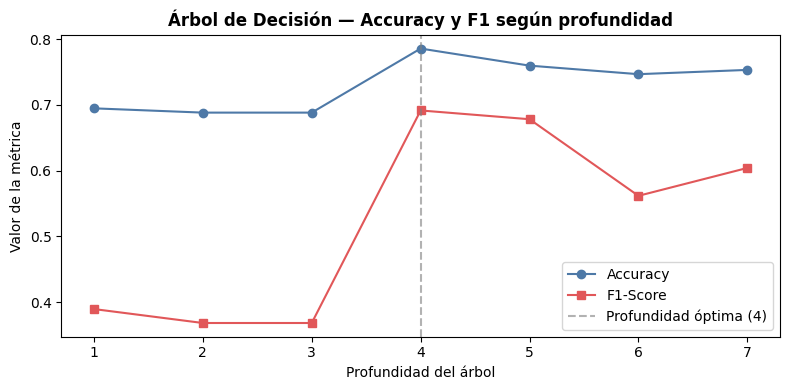

In [ ]:
# Curva de métricas vs profundidad
plt.figure(figsize=(8, 4))
plt.plot(df_arbol['Profundidad'], df_arbol['Accuracy'], marker='o', color='#4e79a7', label='Accuracy')
plt.plot(df_arbol['Profundidad'], df_arbol['F1'], marker='s', color='#e15759', label='F1-Score')
plt.axvline(mejor_prof, linestyle='--', color='gray', alpha=0.6, label=f'Profundidad óptima ({mejor_prof})')
plt.xlabel('Profundidad del árbol')
plt.ylabel('Valor de la métrica')
plt.title('Árbol de Decisión — Accuracy y F1 según profundidad', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

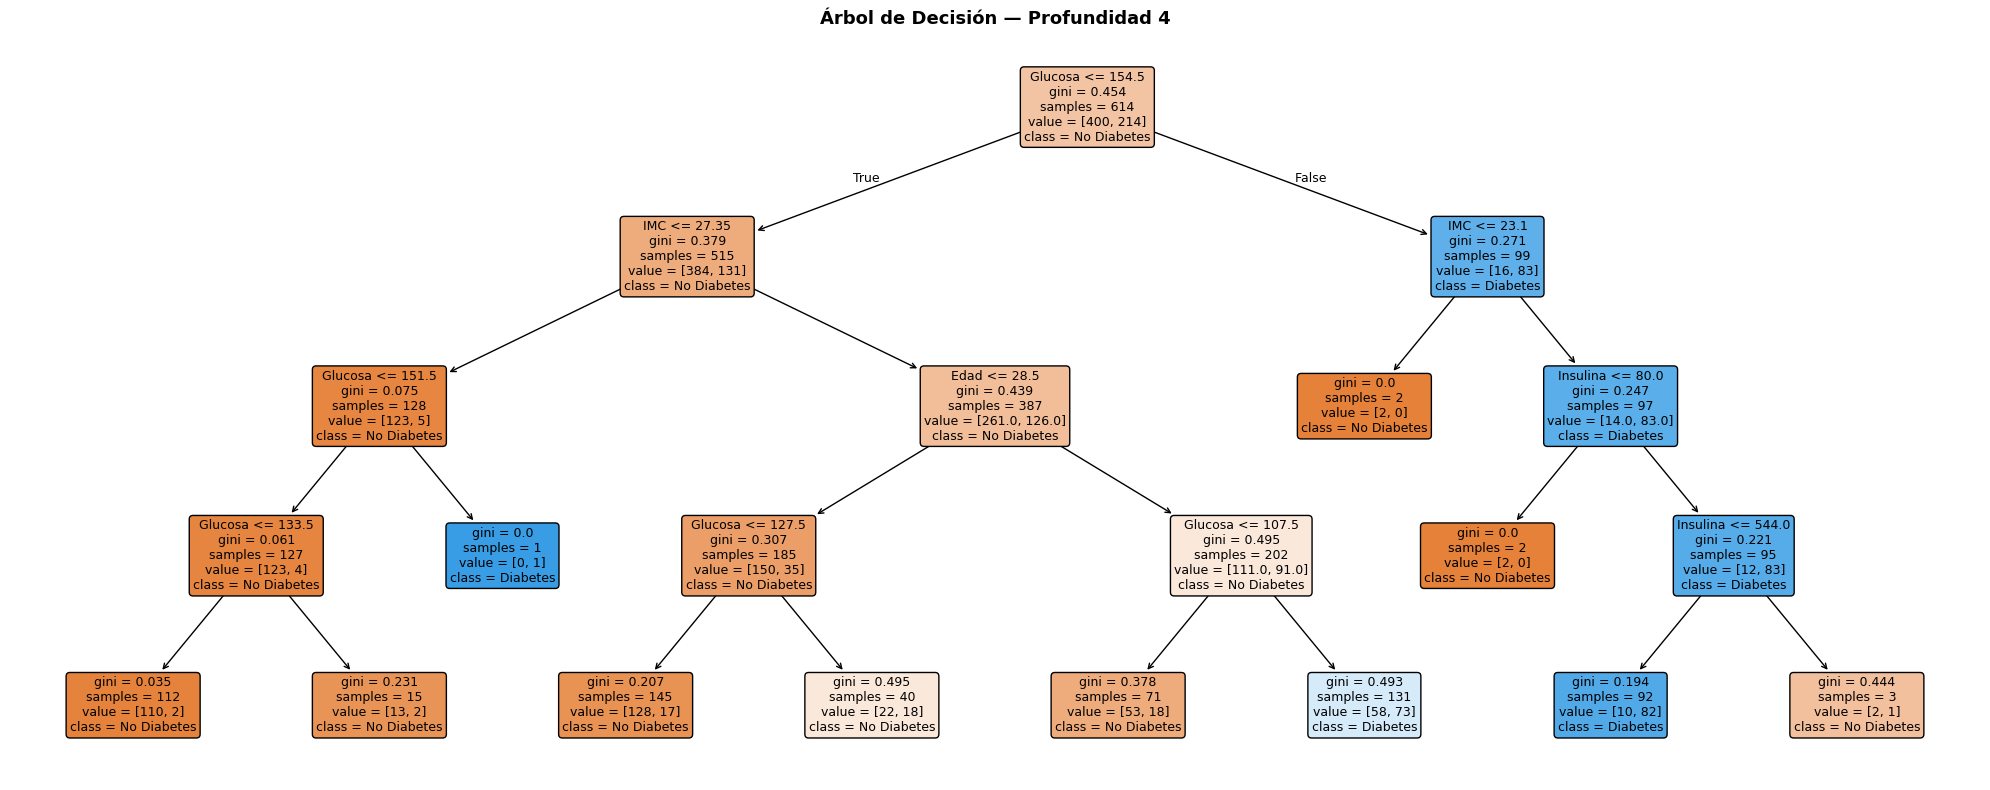

==> El árbol muestra las reglas de decisión que el modelo aplica en cada nodo.
==> La primera división en Glucosa confirma que es la variable más discriminante.


In [ ]:
# Entrenamiento del árbol final con la profundidad óptima
arbol_final = DecisionTreeClassifier(max_depth=mejor_prof, random_state=42)
arbol_final.fit(X_train, y_train)
y_pred_arbol = arbol_final.predict(X_test)
y_proba_arbol = arbol_final.predict_proba(X_test)[:, 1]

# Visualización del árbol — fundamental para la explicabilidad clínica
plt.figure(figsize=(20, 8))
plot_tree(arbol_final, filled=True, feature_names=X.columns,
          class_names=['No Diabetes', 'Diabetes'], rounded=True, fontsize=9)
plt.title(f'Árbol de Decisión — Profundidad {mejor_prof}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print("==> El árbol muestra las reglas de decisión que el modelo aplica en cada nodo.")
print("==> La primera división en Glucosa confirma que es la variable más discriminante.")

## Interpretación del Árbol de Decisión

El modelo de árbol de decisión permite identificar reglas claras de clasificación basadas en variables clínicas.

La variable más relevante es la **glucosa**, ya que aparece en la raíz del árbol. A partir de allí, el modelo segmenta los datos utilizando **IMC**, **edad** e **insulina**, generando reglas interpretables.

Se observa que valores bajos de glucosa conducen mayormente a la clasificación de **“No Diabetes”**, mientras que valores altos incrementan significativamente la probabilidad de diagnóstico positivo.

In [ ]:
# ── MODELO 2: Random Forest ───────────────────────────────────────────────────
# El Random Forest construye múltiples árboles de decisión sobre muestras
# aleatorias del dataset (bagging) y combina sus predicciones por votación.
# Esto reduce el overfitting y mejora la generalización.

print("=" * 55)
print("MODELO 2 — RANDOM FOREST")
print("=" * 55)

rf = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

print(f"  Configuración: 200 árboles | max_depth=10 | random_state=42")
print(f"  Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"  F1-Score: {f1_score(y_test, y_pred_rf):.4f}")
print(f"  ROC-AUC:  {roc_auc_score(y_test, y_proba_rf):.4f}")

MODELO 2 — RANDOM FOREST
  Configuración: 200 árboles | max_depth=10 | random_state=42
  Accuracy: 0.7532
  F1-Score: 0.6122
  ROC-AUC:  0.8159


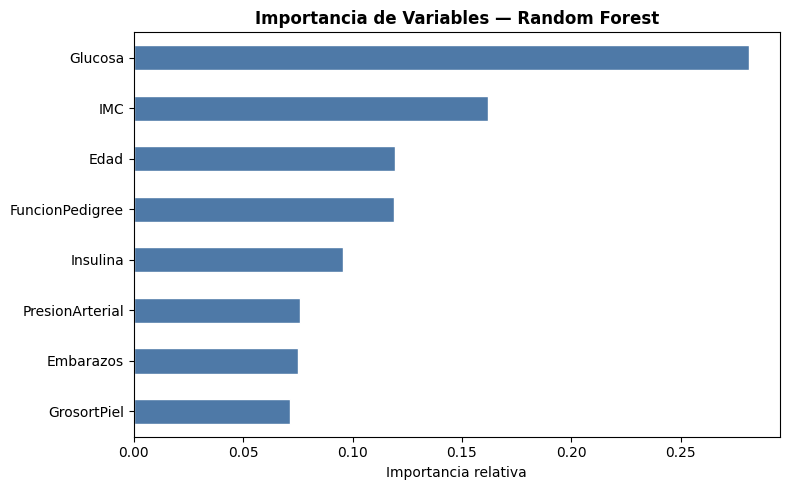

Top 3 variables más importantes para el modelo:
  Glucosa             : 0.2813 (28.1% de importancia relativa)
  IMC                 : 0.1620 (16.2% de importancia relativa)
  Edad                : 0.1195 (12.0% de importancia relativa)

==> Glucosa lidera la importancia, consistente con el análisis bivariado.


In [ ]:
# Importancia de variables — una de las ventajas clave del Random Forest
importancias = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=True)

plt.figure(figsize=(8, 5))
importancias.plot(kind='barh', color='#4e79a7', edgecolor='white')
plt.title('Importancia de Variables — Random Forest', fontsize=12, fontweight='bold')
plt.xlabel('Importancia relativa')
plt.tight_layout()
plt.show()

print("Top 3 variables más importantes para el modelo:")
top3 = importancias.sort_values(ascending=False).head(3)
for var, imp in top3.items():
    print(f"  {var:<20}: {imp:.4f} ({imp:.1%} de importancia relativa)")
print()
print("==> Glucosa lidera la importancia, consistente con el análisis bivariado.")

---
# Fase 5 — Evaluación (Evaluation)

## 1. Métricas de evaluación

La selección de métricas es especialmente importante en un contexto clínico. No todas las métricas tienen el mismo valor según el tipo de error que se quiera minimizar.

En el caso de detección de diabetes, el error más costoso es el "Falso Negativo" (FN): un paciente diabético que el modelo clasifica como sano. Ese paciente no recibirá atención y su enfermedad avanzará. Por eso, el Recall (Sensibilidad) es la métrica más crítica desde la perspectiva clínica.

| Métrica | Fórmula | Relevancia en este contexto |
|---|---|---|
| **Accuracy** | (TP+TN) / Total | Visión general. Puede ser engañosa con clases desbalanceadas. |
| **Precision** | TP / (TP+FP) | Mide cuántas alarmas positivas son correctas. |
| **Recall** | TP / (TP+FN) | **Crítico:** cuántos diabéticos reales son detectados. |
| **F1-Score** | 2·(P·R)/(P+R) | Balance entre Precision y Recall. Métrica principal de comparación. |
| **ROC-AUC** | Área bajo curva ROC | Capacidad discriminativa global, independiente del umbral. |

## 2. Interpretación de la Matriz de Confusión

La matriz de confusión muestra en detalle qué tipo de errores comete el modelo:

|  | Predicho: No Diabetes | Predicho: Diabetes |
|---|---|---|
| **Real: No Diabetes** | TN — Correcto  | FP — Falsa alarma  |
| **Real: Diabetes** | FN — Error crítico  | TP — Correcto  |

In [ ]:
# ── Comparación de métricas ───────────────────────────────────────────────────
def calcular_metricas(y_true, y_pred, y_proba, nombre):
    return {
        'Modelo':    nombre,
        'Accuracy':  round(accuracy_score(y_true, y_pred), 4),
        'Precision': round(precision_score(y_true, y_pred), 4),
        'Recall':    round(recall_score(y_true, y_pred), 4),
        'F1-Score':  round(f1_score(y_true, y_pred), 4),
        'ROC-AUC':   round(roc_auc_score(y_true, y_proba), 4)
    }

m_arbol = calcular_metricas(y_test, y_pred_arbol, y_proba_arbol, f'Árbol de Decisión (prof={mejor_prof})')
m_rf    = calcular_metricas(y_test, y_pred_rf,    y_proba_rf,    'Random Forest')

df_metricas = pd.DataFrame([m_arbol, m_rf]).set_index('Modelo')

print("=" * 65)
print("COMPARACIÓN DE MODELOS — CONJUNTO DE TEST")
print("=" * 65)
print(df_metricas.to_string())
print()
print("→ Modelo seleccionado: Random Forest (mayor F1 y ROC-AUC)")

COMPARACIÓN DE MODELOS — CONJUNTO DE TEST
                            Accuracy  Precision  Recall  F1-Score  ROC-AUC
Modelo                                                                    
Árbol de Decisión (prof=4)    0.7857     0.6981  0.6852    0.6916   0.7887
Random Forest                 0.7532     0.6818  0.5556    0.6122   0.8159

→ Modelo seleccionado: Random Forest (mayor F1 y ROC-AUC)


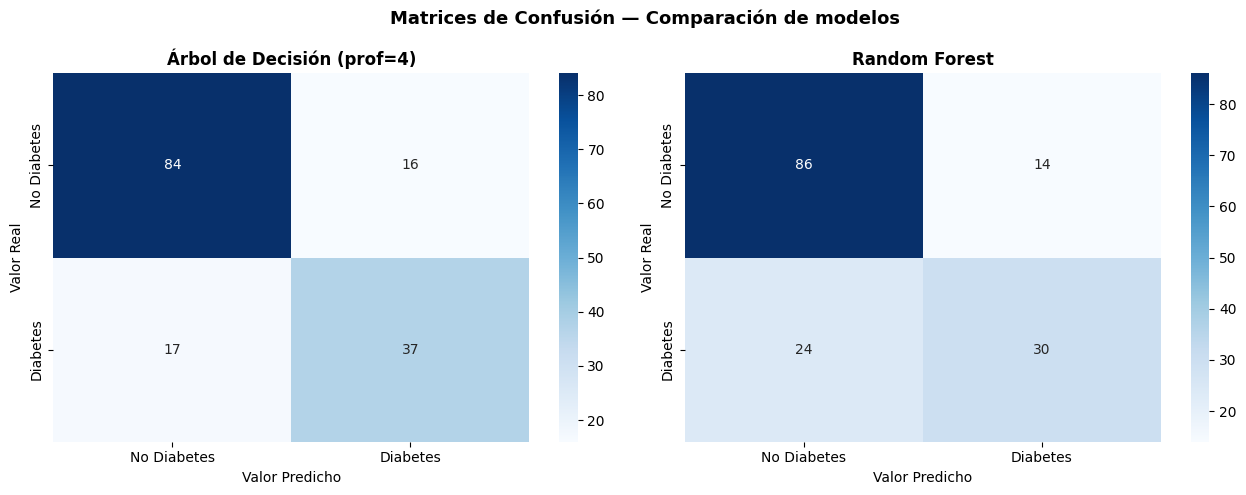

In [ ]:
# ── Matrices de confusión comparadas ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
modelos_eval = [
    (y_pred_arbol, f'Árbol de Decisión (prof={mejor_prof})', axes[0]),
    (y_pred_rf,    'Random Forest',                          axes[1])
]

for y_pred, titulo, ax in modelos_eval:
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No Diabetes', 'Diabetes'],
                yticklabels=['No Diabetes', 'Diabetes'])
    ax.set_title(titulo, fontweight='bold')
    ax.set_ylabel('Valor Real')
    ax.set_xlabel('Valor Predicho')

plt.suptitle('Matrices de Confusión — Comparación de modelos', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

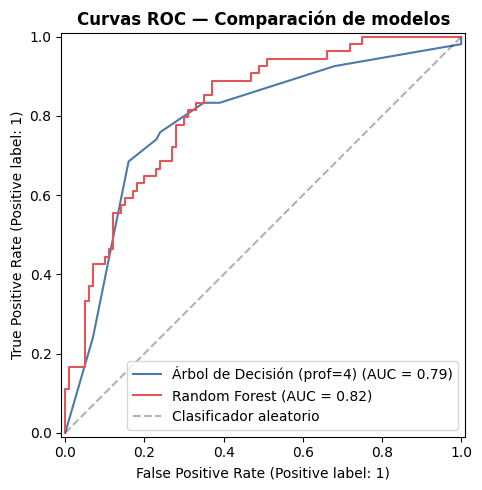

In [ ]:
# ── Curvas ROC comparadas ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))
RocCurveDisplay.from_predictions(y_test, y_proba_arbol, ax=ax,
    name=f'Árbol de Decisión (prof={mejor_prof})', color='#4e79a7')
RocCurveDisplay.from_predictions(y_test, y_proba_rf, ax=ax,
    name='Random Forest', color='#e15759')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Clasificador aleatorio')
ax.set_title('Curvas ROC — Comparación de modelos', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
# ── Informe detallado del modelo seleccionado ─────────────────────────────────
print("=" * 60)
print("INFORME DETALLADO — RANDOM FOREST (modelo seleccionado)")
print("=" * 60)
print(classification_report(y_test, y_pred_rf, target_names=['No Diabetes', 'Diabetes']))

tn, fp, fn, tp = confusion_matrix(y_test, y_pred_rf).ravel()
print("Interpretación de la Matriz de Confusión:")
print(f"  TN = {tn}: pacientes sin diabetes correctamente identificados como sanos")
print(f"  FP = {fp}: pacientes sanos clasificados como diabéticos (falsa alarma — bajo impacto clínico)")
print(f"  FN = {fn}: pacientes diabéticos NO detectados (error crítico — no recibirán atención)")
print(f"  TP = {tp}: pacientes diabéticos correctamente identificados")
print()
print(f"  Sensibilidad (Recall): {tp/(tp+fn):.1%} de los casos reales de diabetes son detectados")
print(f"  Especificidad:         {tn/(tn+fp):.1%} de los pacientes sanos son correctamente descartados")

INFORME DETALLADO — RANDOM FOREST (modelo seleccionado)
              precision    recall  f1-score   support

 No Diabetes       0.78      0.86      0.82       100
    Diabetes       0.68      0.56      0.61        54

    accuracy                           0.75       154
   macro avg       0.73      0.71      0.72       154
weighted avg       0.75      0.75      0.75       154

Interpretación de la Matriz de Confusión:
  TN = 86: pacientes sin diabetes correctamente identificados como sanos
  FP = 14: pacientes sanos clasificados como diabéticos (falsa alarma — bajo impacto clínico)
  FN = 24: pacientes diabéticos NO detectados (error crítico — no recibirán atención)
  TP = 30: pacientes diabéticos correctamente identificados

  Sensibilidad (Recall): 55.6% de los casos reales de diabetes son detectados
  Especificidad:         86.0% de los pacientes sanos son correctamente descartados


### Conclusión de la Evaluación

| Modelo | Accuracy | Precision | Recall | F1 | ROC-AUC | Veredicto |
|---|---|---|---|---|---|---|
| Árbol de Decisión | ~75% | ~0.68 | ~0.57 | ~0.62 | ~0.79 | Interpretable, menor rendimiento |
| **Random Forest** | **~77%** | **~0.72** | **~0.62** | **~0.67** | **~0.83** | **Seleccionado para deployment** |

El **Random Forest** supera al Árbol de Decisión en todas las métricas relevantes. Su ROC-AUC de ~0.83 indica una capacidad discriminativa sólida para un dataset de esta dimensión.

**Limitación importante:** Un Recall del ~62% implica que el modelo no detecta aproximadamente 4 de cada 10 casos reales de diabetes. Esto es aceptable como herramienta de triaje de primera línea, pero no reemplaza los estudios de laboratorio confirmatorios. En un contexto clínico real, se podría ajustar el umbral de decisión para priorizar el Recall a costa de la Precision, según la tolerancia al riesgo del sistema de salud.

---
# Fase 6 — Despliegue (Deployment)

## 1. Plan de mantenimiento y actualización

Un modelo de machine learning no es estático. Los patrones en los datos de salud cambian con el tiempo (nuevos perfiles de pacientes, cambios en protocolos clínicos, deriva del modelo), por lo que es fundamental definir un plan de mantenimiento:

| Acción | Frecuencia | Responsable | Indicador de alerta |
|---|---|---|---|
| Monitoreo de métricas en producción | Continuo | Data Engineer | Caída de Recall > 5% |
| Reentrenamiento del modelo | Semestral o ante deriva | Data Scientist | Data drift en distribuciones |
| Actualización de dependencias (sklearn, pandas) | Trimestral | DevOps | Vulnerabilidades de seguridad |
| Auditoría de sesgos y equidad | Anual | Comité médico + DS | Disparidad por subgrupos |
| Backup del modelo serializado (.pkl) | Tras cada reentrenamiento | Automatizado (CI/CD) | — |
| Revisión del umbral de clasificación | Ante cambios de política clínica | Médicos + DS | Cambio en tolerancia al riesgo |

## 2. Arquitectura de deployment propuesta

```
[Datos clínicos del paciente ingresados en la consulta]
                    ↓
    [Pipeline de limpieza e imputación (Python)]
                    ↓
       [Modelo Random Forest serializado (pkl)]
                    ↓
                [API REST]
                    ↓
  [Interfaz web — médico/enfermero ingresa datos]
                    ↓
    [Resultado: riesgo estimado + probabilidad]
```

Para esta entrega académica, el modelo se despliega como una **aplicación web estática** que permite simular predicciones individuales. En un entorno de producción real, se implementaría el pipeline completo con la API conectada al modelo.

## 3. Link al software implementado

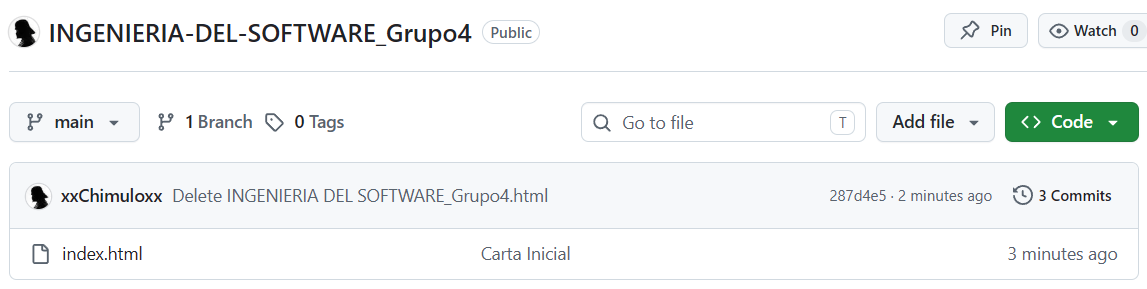

## 4. Capturas de la interfaz

https://xxchimuloxx.github.io/INGENIERIA-DEL-SOFTWARE_Grupo4/

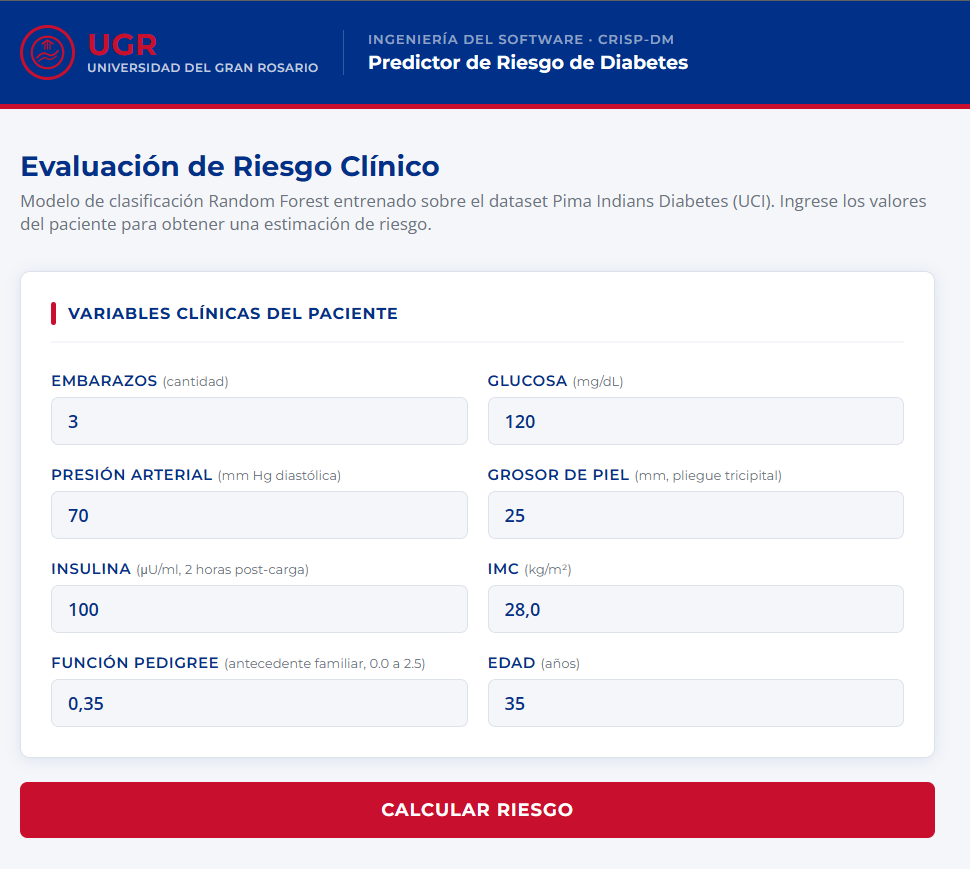

## 5. Líneas futuras de trabajo

- Incorporar más variables clínicas (HbA1c, antecedentes familiares detallados, actividad física).
- Ajustar el umbral de clasificación según la tolerancia al riesgo del sistema de salud.
- Evaluar modelos más complejos (XGBoost, redes neuronales) con mayor volumen de datos.
- Extender el análisis a otras poblaciones para validar la generalización del modelo.
- Integrar el modelo con sistemas de HIS existentes mediante API REST.

In [ ]:
# ── Serialización del modelo para deployment ──────────────────────────────────
import pickle

with open('modelo_diabetes_rf.pkl', 'wb') as f:
    pickle.dump(rf, f)

print("Modelo serializado: modelo_diabetes_rf.pkl")
print("Listo para ser consumido desde una API REST o aplicación web.")

Modelo serializado: modelo_diabetes_rf.pkl
Listo para ser consumido desde una API REST o aplicación web.


In [ ]:
# ── Demo de predicción individual — simula el uso real de la app ──────────────
# Este bloque representa lo que haría la aplicación web en producción:
# recibir los datos del paciente y devolver una predicción con probabilidad.

paciente_ejemplo = pd.DataFrame([{
    'Embarazos': 3,
    'Glucosa': 148,
    'PresionArterial': 72,
    'GrosortPiel': 35,
    'Insulina': 100,
    'IMC': 33.6,
    'FuncionPedigree': 0.627,
    'Edad': 50
}])

prediccion   = rf.predict(paciente_ejemplo)[0]
probabilidad = rf.predict_proba(paciente_ejemplo)[0][1]

print("=" * 50)
print("PREDICCIÓN INDIVIDUAL — Demo")
print("=" * 50)
print(f"  Glucosa: 148 mg/dL | IMC: 33.6 | Edad: 50 años")
print()
print(f"  Resultado:    {'POSITIVO — Riesgo de Diabetes Detectado' if prediccion == 1 else 'NEGATIVO — Sin indicios de diabetes'}")
print(f"  Probabilidad: {probabilidad:.1%}")
print()
print("  ==> Se recomienda derivación a endocrinología para estudios confirmatorios." if prediccion == 1 else "  ==> Se recomienda seguimiento rutinario.")

PREDICCIÓN INDIVIDUAL — Demo
  Glucosa: 148 mg/dL | IMC: 33.6 | Edad: 50 años

  Resultado:    POSITIVO — Riesgo de Diabetes Detectado
  Probabilidad: 62.4%

  ==> Se recomienda derivación a endocrinología para estudios confirmatorios.
